
# CICIoT2023 — Post-Balancing Data Understanding & Professional Preprocessing

**Project:** Quantum-Inspired Federated Framework for Dynamic IoT Networks  
**Use case:** CICIoT2023 intrusion detection after augmentation + training balance  
**Goal:** build a **clean, validated, documented, training-ready** dataset bundle for:
- centralized learning
- hierarchical learning
- federated learning
- future quantum-inspired modules

---

## Why this notebook exists

This notebook upgrades the previous post-balancing workflow with several important corrections and improvements:

1. **Representative EDA**
   - no more `nrows`-only biased analysis from the top of the CSV
   - uses **stratified sampling per class** for EDA

2. **Safer cleaning policy**
   - drops **constant features automatically**
   - keeps **near-constant features under review** by default
   - handles `NaN` / `Inf` correctly
   - removes duplicates **from train split only**

3. **Professional preprocessing artifacts**
   - stable label encoding from train
   - class weights from train
   - scaler fit on train only
   - selected feature list
   - preprocessing summary and sanity checks

4. **Better reporting**
   - figures for class distribution
   - before/after preprocessing comparison
   - retention ratio verification
   - correlation heatmap
   - feature audit reports

---

## Main source paths recovered from your balancing notebook

- original clean dataset: `E:\dataset\processed\merged_full\dataset_34classes_clean.csv`
- balanced dataset: `E:\dataset\processed_merged_full\minority_balancing_v3\dataset_34classes_balanced_v3.csv`
- synthetic-only dataset: `E:\dataset\processed_merged_full\minority_balancing_v3\synthetic_only_v3.csv`
- base balanced without synthetic: `E:\dataset\processed_merged_full\minority_balancing_v3\base_balanced_without_synthetic_v3.csv`
- old training-ready dir: `E:\dataset\processed_merged_full\minority_balancing_v3\training_ready`

These paths come directly from your previous augmentation/training-balance notebook.


## Workflow overview

```text
STEP 1 — LOAD
    Load available datasets, verify existence and shapes

STEP 2 — EDA
    dtypes, NaN/Inf, duplicates, class distribution
    constant / near-constant features
    distributions, outliers, correlation heatmap

STEP 3 — CLEAN
    Replace Inf -> NaN -> median
    drop constant features
    optional near-constant review
    optional correlated-feature pruning
    remove duplicates from train only

STEP 4 — LABEL ENCODING
    stable 34-class mapping fitted on train only

STEP 5 — CLASS WEIGHTS
    compute balanced class weights from train only

STEP 6 — SCALING
    RobustScaler fitted on train only
    cast features to float32

STEP 7 — SAVE ARTIFACTS
    CSV / NPZ / PKL / JSON + sanity checks + report figures
```


In [1]:

from pathlib import Path
import os
import json
import gc
import warnings
import pickle
from typing import Optional, List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)


## 1. Configuration

In [2]:

# ============================================================
# CONFIGURATION
# ============================================================

ORIGINAL_CLEAN_DATASET = Path(r"E:\dataset\processed\merged_full\dataset_34classes_clean.csv")
BALANCED_DATASET = Path(r"E:\dataset\processed_merged_full\minority_balancing_v3\dataset_34classes_balanced_v3.csv")
SYNTHETIC_ONLY_DATASET = Path(r"E:\dataset\processed_merged_full\minority_balancing_v3\synthetic_only_v3.csv")
BASE_BALANCED_DATASET = Path(r"E:\dataset\processed_merged_full\minority_balancing_v3\base_balanced_without_synthetic_v3.csv")
OLD_TRAINING_READY_DIR = Path(r"E:\dataset\processed_merged_full\minority_balancing_v3\training_ready")

# Portable override if needed
PROJECT_ROOT = None
if PROJECT_ROOT is not None:
    ORIGINAL_CLEAN_DATASET = PROJECT_ROOT / "processed/merged_full/dataset_34classes_clean.csv"
    BALANCED_DATASET = PROJECT_ROOT / "processed_merged_full/minority_balancing_v3/dataset_34classes_balanced_v3.csv"
    SYNTHETIC_ONLY_DATASET = PROJECT_ROOT / "processed_merged_full/minority_balancing_v3/synthetic_only_v3.csv"
    BASE_BALANCED_DATASET = PROJECT_ROOT / "processed_merged_full/minority_balancing_v3/base_balanced_without_synthetic_v3.csv"
    OLD_TRAINING_READY_DIR = PROJECT_ROOT / "processed_merged_full/minority_balancing_v3/training_ready"

INPUT_DATASET = BALANCED_DATASET
LABEL_COL = "label"
LABEL_ID_COL_CANDIDATE = "label_id_34"

OUTPUT_DIR = INPUT_DATASET.parent / "post_balancing_preprocessing_professional_v2"
ARTIFACTS_DIR = OUTPUT_DIR / "artifacts"
REPORTS_DIR = OUTPUT_DIR / "reports"
FIGURES_DIR = OUTPUT_DIR / "figures"
EXPORTS_DIR = OUTPUT_DIR / "exports"
for p in [OUTPUT_DIR, ARTIFACTS_DIR, REPORTS_DIR, FIGURES_DIR, EXPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# EDA controls
EDA_ROWS_PER_CLASS = 5000          # representative stratified sample
CORR_ROWS = 50000                  # sample used for correlation heatmap
PLOT_MAX_FEATURES = 10

# Train/val/test
TEST_RATIO = 0.20
USE_VALIDATION = True
VAL_RATIO_FROM_TRAIN = 0.125       # gives ~70/10/20 overall

# Cleaning controls
DROP_DUPLICATES_TRAIN_ONLY = True
REMOVE_CONSTANT_FEATURES = True
REMOVE_NEAR_CONSTANT_FEATURES = False   # keep under review first
NEAR_CONSTANT_THRESHOLD = 0.999         # inspired by your engineering workflow (>99.9%)
REMOVE_HIGH_CORR_FEATURES = False
HIGH_CORR_THRESHOLD = 0.98

# Transformation controls
MISSING_NUMERIC_STRATEGY = "median"
SCALER_NAME = "robust"  # or "standard"
APPLY_LOG1P_TO_HEAVY_SKEW = False
SKEW_THRESHOLD_FOR_LOG1P = 5.0
CAST_FLOAT32 = True

# Exports
EXPORT_CSV = True
EXPORT_PARQUET = False
EXPORT_NPZ = True

print("INPUT_DATASET:", INPUT_DATASET)
print("OUTPUT_DIR   :", OUTPUT_DIR)


INPUT_DATASET: E:\dataset\processed_merged_full\minority_balancing_v3\dataset_34classes_balanced_v3.csv
OUTPUT_DIR   : E:\dataset\processed_merged_full\minority_balancing_v3\post_balancing_preprocessing_professional_v2


## 2. File inventory

In [3]:

file_inventory = pd.DataFrame([
    {"name": "original_clean_dataset", "path": str(ORIGINAL_CLEAN_DATASET), "exists": ORIGINAL_CLEAN_DATASET.exists()},
    {"name": "balanced_dataset", "path": str(BALANCED_DATASET), "exists": BALANCED_DATASET.exists()},
    {"name": "synthetic_only_dataset", "path": str(SYNTHETIC_ONLY_DATASET), "exists": SYNTHETIC_ONLY_DATASET.exists()},
    {"name": "base_balanced_dataset", "path": str(BASE_BALANCED_DATASET), "exists": BASE_BALANCED_DATASET.exists()},
    {"name": "old_training_ready_dir", "path": str(OLD_TRAINING_READY_DIR), "exists": OLD_TRAINING_READY_DIR.exists()},
])
file_inventory


,name,path,exists
0,original_clean_dataset,E:\dataset\processed\merged_full\dataset_34cla...,True
1,balanced_dataset,E:\dataset\processed_merged_full\minority_bala...,True
2,synthetic_only_dataset,E:\dataset\processed_merged_full\minority_bala...,True
3,base_balanced_dataset,E:\dataset\processed_merged_full\minority_bala...,True
4,old_training_ready_dir,E:\dataset\processed_merged_full\minority_bala...,True


## 3. Utility functions

In [4]:

def read_csv_safely(path: Path, nrows: Optional[int] = None) -> pd.DataFrame:
    assert path.exists(), f"File not found: {path}"
    return pd.read_csv(path, nrows=nrows)


def save_json(obj, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def detect_feature_columns(df: pd.DataFrame, label_col: str, label_id_candidate: str) -> Tuple[List[str], List[str], List[str]]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude = [c for c in [label_id_candidate] if c in numeric_cols]
    feature_cols = [c for c in numeric_cols if c not in exclude]
    object_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    return numeric_cols, feature_cols, object_cols


def stratified_sample_per_class(df: pd.DataFrame, label_col: str, n_per_class: int, seed: int = 42) -> pd.DataFrame:
    parts = []
    for label, g in df.groupby(label_col, sort=False):
        parts.append(g.sample(n=min(len(g), n_per_class), random_state=seed))
    return pd.concat(parts, ignore_index=True)


def summarize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        row = {
            "column": col,
            "dtype": str(s.dtype),
            "missing": int(s.isna().sum()),
            "missing_ratio": float(s.isna().mean()),
            "n_unique": int(s.nunique(dropna=False)),
            "is_numeric": bool(pd.api.types.is_numeric_dtype(s)),
        }
        if pd.api.types.is_numeric_dtype(s):
            vc = s.value_counts(dropna=False, normalize=True)
            row.update({
                "min": float(s.min()) if len(s) else np.nan,
                "q01": float(s.quantile(0.01)) if len(s) else np.nan,
                "median": float(s.median()) if len(s) else np.nan,
                "mean": float(s.mean()) if len(s) else np.nan,
                "q99": float(s.quantile(0.99)) if len(s) else np.nan,
                "max": float(s.max()) if len(s) else np.nan,
                "std": float(s.std(ddof=0)) if len(s) else np.nan,
                "skew": float(s.skew()) if len(s) else np.nan,
                "zero_ratio": float((s == 0).mean()) if len(s) else np.nan,
                "top_value_ratio": float(vc.iloc[0]) if len(vc) else np.nan,
            })
        else:
            vc = s.value_counts(dropna=False, normalize=True)
            row.update({
                "min": None, "q01": None, "median": None, "mean": None,
                "q99": None, "max": None, "std": None, "skew": None,
                "zero_ratio": None,
                "top_value_ratio": float(vc.iloc[0]) if len(vc) else np.nan,
            })
        rows.append(row)
    out = pd.DataFrame(rows)
    out["is_constant"] = out["n_unique"] <= 1
    out["is_near_constant"] = out["top_value_ratio"].fillna(0) >= NEAR_CONSTANT_THRESHOLD
    return out


def iqr_outlier_ratio(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return float(((s < low) | (s > high)).mean())


def build_feature_quality_report(df: pd.DataFrame, feature_cols: List[str]) -> pd.DataFrame:
    rows = []
    for col in feature_cols:
        s = pd.to_numeric(df[col], errors="coerce")
        vc = s.value_counts(dropna=False, normalize=True)
        rows.append({
            "feature": col,
            "missing": int(s.isna().sum()),
            "missing_ratio": float(s.isna().mean()),
            "n_unique": int(s.nunique(dropna=False)),
            "zero_ratio": float((s == 0).mean()),
            "std": float(s.std(ddof=0)),
            "skew": float(s.skew()),
            "iqr_outlier_ratio": iqr_outlier_ratio(s),
            "is_constant": bool(s.nunique(dropna=False) <= 1),
            "top_value_ratio": float(vc.iloc[0]) if len(vc) else np.nan,
            "is_near_constant": bool((float(vc.iloc[0]) if len(vc) else 0.0) >= NEAR_CONSTANT_THRESHOLD),
        })
    return pd.DataFrame(rows).sort_values(["is_constant", "is_near_constant", "missing_ratio", "iqr_outlier_ratio"], ascending=[False, False, False, False])


def correlation_drop_candidates(df: pd.DataFrame, feature_cols: List[str], threshold: float = 0.98) -> pd.DataFrame:
    corr = df[feature_cols].corr(method="spearman").abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = []
    for col in upper.columns:
        strong = upper[col][upper[col] > threshold]
        for idx, val in strong.items():
            pairs.append({"feature_a": idx, "feature_b": col, "abs_spearman": float(val)})
    if len(pairs) == 0:
        return pd.DataFrame(columns=["feature_a", "feature_b", "abs_spearman"])
    return pd.DataFrame(pairs).sort_values("abs_spearman", ascending=False)


def fit_scaler(name: str):
    if name.lower() == "robust":
        return RobustScaler()
    if name.lower() == "standard":
        return StandardScaler()
    raise ValueError(f"Unsupported scaler: {name}")


def optional_log1p_transform(train_df, val_df, test_df, feature_cols, skew_threshold=5.0):
    skew_vals = train_df[feature_cols].skew().abs()
    candidates = skew_vals[skew_vals > skew_threshold].index.tolist()
    safe_candidates = [c for c in candidates if train_df[c].min() >= 0]
    for d in [train_df, val_df, test_df]:
        if d is None:
            continue
        for c in safe_candidates:
            d[c] = np.log1p(d[c])
    return train_df, val_df, test_df, safe_candidates


## 4. Load datasets and build representative EDA sample

In [5]:

full_input_df = read_csv_safely(INPUT_DATASET)
print("Full balanced dataset shape:", full_input_df.shape)
full_input_df.head()


Full balanced dataset shape: (10200000, 34)


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,ack_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IGMP,Tot sum,Min,Max,AVG,Std,IAT,Number,Variance,label,label_id_34
0,0.20,1.0,65.91,23952.396,0.0,0.00,0.01,0.00,0.01,0.0,1.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.99,0.0,6000.0,60.0,60.0,60.00,0.00000,0.000042,100.0,0.00000,DDOS-ICMP_FLOOD,6.0
1,0.28,1.0,63.79,42499.790,0.0,0.01,0.00,0.00,0.01,0.0,1.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.99,0.0,6002.0,60.0,62.0,60.02,0.20000,0.000024,100.0,0.04000,DDOS-ICMP_FLOOD,6.0
2,0.00,1.0,64.00,20538.164,0.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1.00,0.0,6000.0,60.0,60.0,60.00,0.00000,0.000049,100.0,0.00000,DDOS-ICMP_FLOOD,6.0
3,0.64,1.0,67.48,72716.780,0.0,0.00,0.00,0.01,0.02,0.0,2.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,0.02,0.0,0.0,0.0,0.98,0.0,6108.0,60.0,162.0,61.08,10.21158,0.000014,100.0,104.27637,DDOS-ICMP_FLOOD,6.0
4,0.32,1.0,63.96,47100.550,0.0,0.00,0.00,0.00,0.01,0.0,1.0,0.0,0.01,0.0,0.0,0.0,0.0,0.0,0.01,0.0,0.0,0.0,0.99,0.0,6006.0,60.0,66.0,60.06,0.60000,0.000021,100.0,0.36000,DDOS-ICMP_FLOOD,6.0


In [6]:

eda_df = stratified_sample_per_class(full_input_df, LABEL_COL, n_per_class=EDA_ROWS_PER_CLASS, seed=SEED)
print("Representative EDA shape:", eda_df.shape)
print("Classes in EDA sample:", eda_df[LABEL_COL].nunique())


Representative EDA shape: (170000, 34)
Classes in EDA sample: 34


In [7]:

numeric_cols, feature_cols, object_cols = detect_feature_columns(eda_df, LABEL_COL, LABEL_ID_COL_CANDIDATE)
print("Numeric columns :", len(numeric_cols))
print("Feature columns :", len(feature_cols))
print("Object columns  :", len(object_cols))
print("Feature preview :", feature_cols[:10])


Numeric columns : 33
Feature columns : 32
Object columns  : 1
Feature preview : ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number']


## 5. Dataset volume and class distribution

In [8]:

class_dist_full = full_input_df[LABEL_COL].value_counts().sort_values(ascending=False)
class_dist_eda = eda_df[LABEL_COL].value_counts().sort_index()

class_dist_full_df = class_dist_full.rename_axis("label").reset_index(name="count")
class_dist_full_df.to_csv(REPORTS_DIR / "class_distribution_full_before_preprocessing.csv", index=False)
class_dist_full_df.head(10)


,label,count
0,DDOS-ICMP_FLOOD,300000
1,DOS-TCP_FLOOD,300000
2,VULNERABILITYSCAN,300000
3,DDOS-ICMP_FRAGMENTATION,300000
4,MIRAI-GREIP_FLOOD,300000
5,MIRAI-UDPPLAIN,300000
6,MIRAI-GREETH_FLOOD,300000
7,BENIGN,300000
8,DOS-SYN_FLOOD,300000
9,DDOS-SLOWLORIS,300000


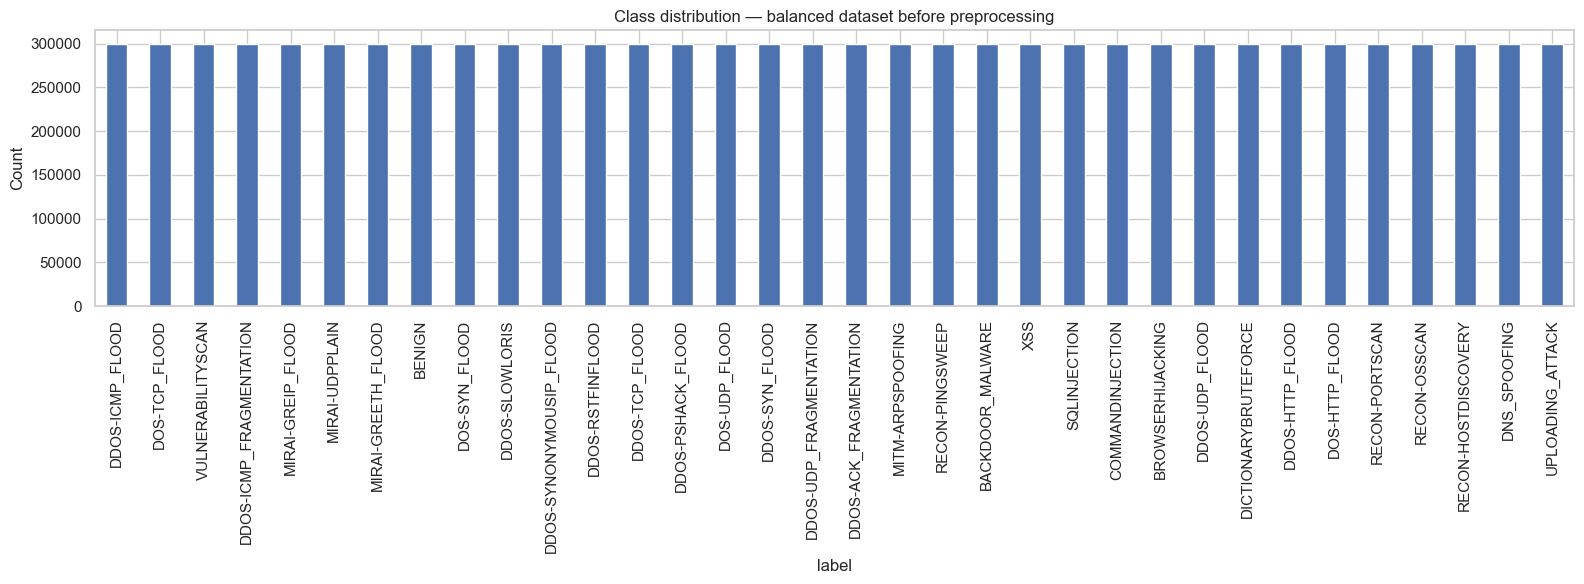

In [9]:

plt.figure(figsize=(16, 6))
class_dist_full.plot(kind="bar")
plt.title("Class distribution — balanced dataset before preprocessing")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution_before_preprocessing.png", dpi=160, bbox_inches="tight")
plt.show()


## 6. Structural profiling and data quality audit

In [10]:

summary_df = summarize_dataframe(eda_df)
summary_df.to_csv(REPORTS_DIR / "column_summary_eda.csv", index=False)
summary_df.head(20)


,column,dtype,missing,missing_ratio,n_unique,is_numeric,min,q01,median,mean,q99,max,std,skew,zero_ratio,top_value_ratio,is_constant,is_near_constant
0,Header_Length,float64,0,0.0,66040,True,0.000000,0.000000,20.000000,18.112516,37.313030,60.00,10.154808,-0.206991,0.057076,0.105465,False,False
1,Protocol Type,float64,0,0.0,19,True,0.000000,1.000000,6.000000,10.315953,47.000000,47.00,10.209983,2.654531,0.003235,0.628900,False,False
2,Time_To_Live,float64,0,0.0,69273,True,0.000000,47.268692,65.670000,80.303019,208.142735,255.00,30.690406,2.347687,0.000106,0.237188,False,False
3,Rate,float64,0,0.0,109127,True,0.041658,10.654698,2836.871948,10980.824257,106616.770000,1997287.60,30748.938021,14.929874,0.000000,0.013676,False,False
4,fin_flag_number,float64,0,0.0,44323,True,0.000000,0.000000,0.000000,0.044559,1.000000,1.00,0.169751,5.106172,0.654359,0.654359,False,False
5,syn_flag_number,float64,0,0.0,49563,True,0.000000,0.000000,0.000000,0.137510,1.000000,1.00,0.292564,2.280770,0.510653,0.510653,False,False
6,rst_flag_number,float64,0,0.0,40762,True,0.000000,0.000000,0.000000,0.063234,1.000000,1.00,0.200415,3.778263,0.673776,0.673776,False,False
7,psh_flag_number,float64,0,0.0,61345,True,0.000000,0.000000,0.010000,0.128318,1.000000,1.00,0.204510,2.379915,0.443353,0.443353,False,False
8,ack_flag_number,float64,0,0.0,62601,True,0.000000,0.000000,0.348424,0.389124,1.000000,1.00,0.380131,0.304789,0.292635,0.292635,False,False
9,ece_flag_number,float64,0,0.0,12122,True,0.000000,0.000000,0.000000,0.000262,0.002097,1.00,0.006095,66.748656,0.927224,0.927224,False,False


In [11]:

# NaN / Inf audit on representative sample
inf_counts = pd.Series({col: np.isinf(pd.to_numeric(eda_df[col], errors="coerce")).sum() for col in feature_cols}).sort_values(ascending=False)
missing_counts = eda_df.isna().sum().sort_values(ascending=False)
duplicate_count = int(eda_df.duplicated().sum())

print("Duplicate rows in EDA sample:", duplicate_count)
print("Top missing counts:")
display(missing_counts.head(20))
print("Top inf counts:")
display(inf_counts.head(20))


Duplicate rows in EDA sample: 0
Top missing counts:


label_id_34      66076
Min                  0
UDP                  0
DHCP                 0
ARP                  0
ICMP                 0
IGMP                 0
Tot sum              0
Max                  0
Protocol Type        0
AVG                  0
Std                  0
IAT                  0
Number               0
Variance             0
label                0
TCP                  0
Header_Length        0
SSH                  0
SMTP                 0
dtype: int64

Top inf counts:


Header_Length    0
Protocol Type    0
Number           0
IAT              0
Std              0
AVG              0
Max              0
Min              0
Tot sum          0
IGMP             0
ICMP             0
ARP              0
DHCP             0
UDP              0
TCP              0
IRC              0
SSH              0
SMTP             0
Telnet           0
DNS              0
dtype: int64

In [12]:

feature_quality_df = build_feature_quality_report(eda_df, feature_cols)
feature_quality_df.to_csv(REPORTS_DIR / "feature_quality_report_eda.csv", index=False)
feature_quality_df.head(20)


,feature,missing,missing_ratio,n_unique,zero_ratio,std,skew,iqr_outlier_ratio,is_constant,top_value_ratio,is_near_constant
14,Telnet,0,0.0,17,0.999153,0.001310,105.042106,0.000000,False,0.999153,True
15,SMTP,0,0.0,14,0.999188,0.001649,145.854123,0.000000,False,0.999188,True
11,HTTP,0,0.0,46978,0.626512,0.267905,2.474609,0.213518,False,0.626512,False
6,rst_flag_number,0,0.0,40762,0.673776,0.200415,3.778263,0.208024,False,0.673776,False
24,Tot sum,0,0.0,31424,0.000000,28350.733310,1.723377,0.203382,False,0.158300,False
4,fin_flag_number,0,0.0,44323,0.654359,0.169751,5.106172,0.187771,False,0.654359,False
22,ICMP,0,0.0,41550,0.637094,0.227203,3.648589,0.186706,False,0.637094,False
21,ARP,0,0.0,47307,0.584559,0.064448,5.219155,0.182747,False,0.584559,False
29,IAT,0,0.0,84792,0.000006,0.090459,190.954206,0.165112,False,0.014606,False
25,Min,0,0.0,1310,0.000000,198.470565,4.887733,0.160882,False,0.591935,False


In [13]:

constant_candidates = feature_quality_df.loc[feature_quality_df["is_constant"], "feature"].tolist()
near_constant_candidates = feature_quality_df.loc[feature_quality_df["is_near_constant"], "feature"].tolist()

print("Constant features:", constant_candidates)
print("Near-constant features (review, not auto-drop unless enabled):", near_constant_candidates)


Constant features: []
Near-constant features (review, not auto-drop unless enabled): ['Telnet', 'SMTP']


## 7. Feature distributions and outliers

In [14]:

plot_cols = [c for c in ["Rate", "IAT", "Variance", "Tot sum", "Header_Length", "Time_To_Live", "Std", "AVG", "Max", "ack_count"] if c in feature_cols][:PLOT_MAX_FEATURES]
plot_cols


['Rate',
 'IAT',
 'Variance',
 'Tot sum',
 'Header_Length',
 'Time_To_Live',
 'Std',
 'AVG',
 'Max',
 'ack_count']

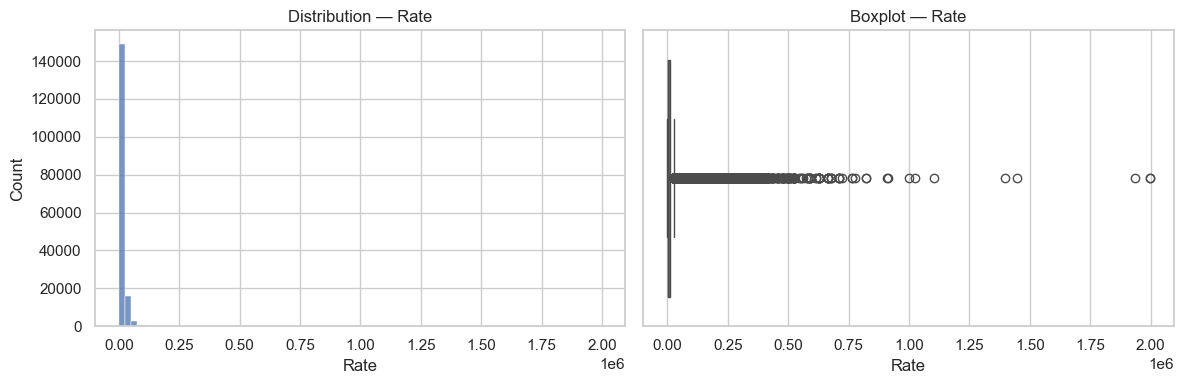

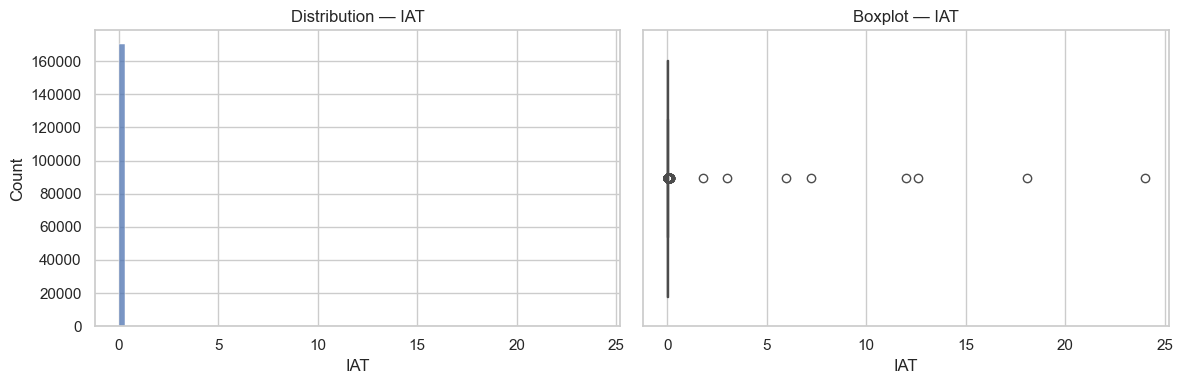

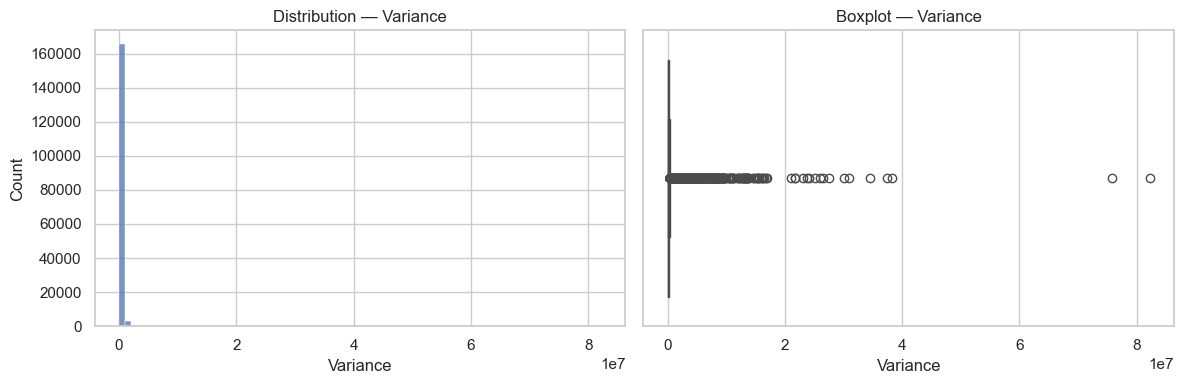

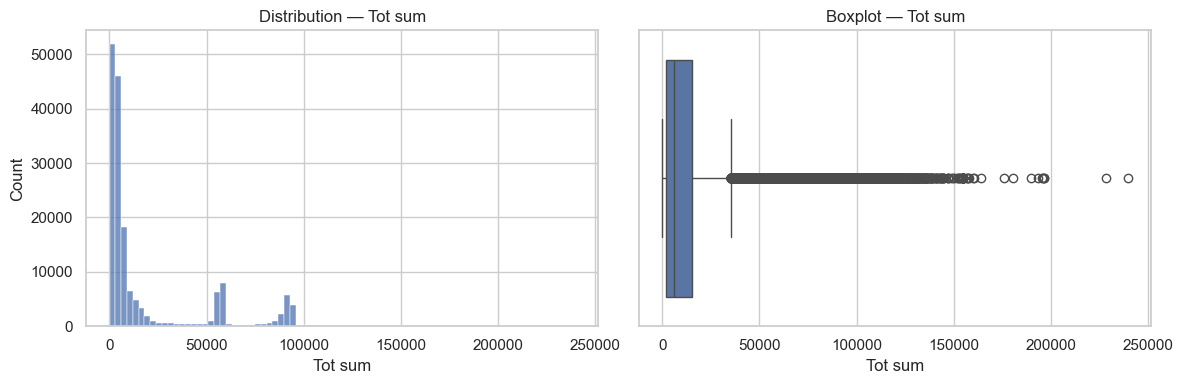

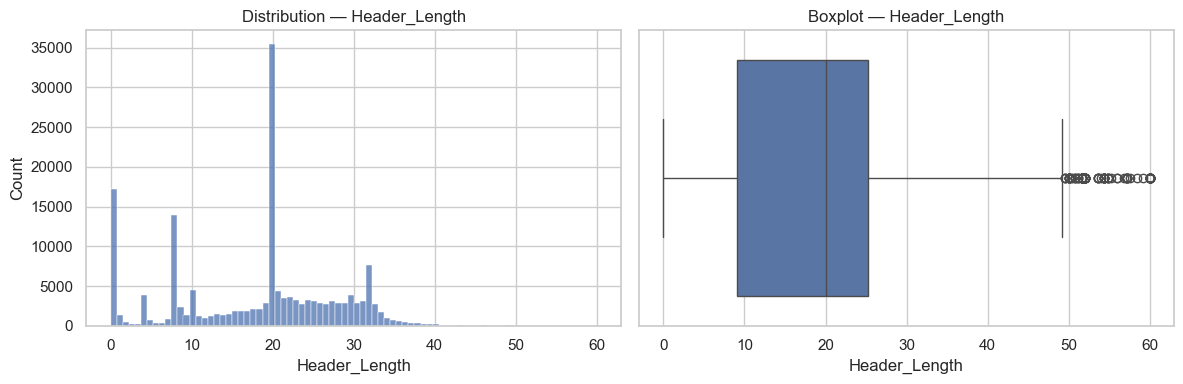

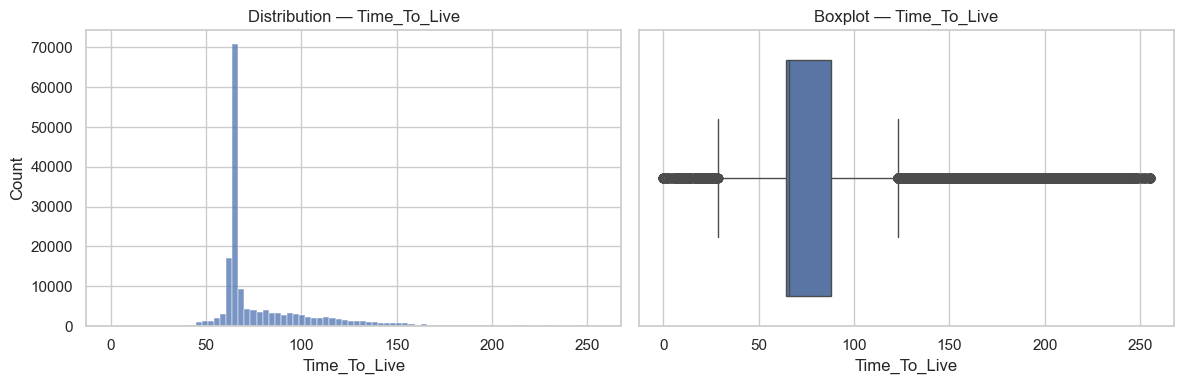

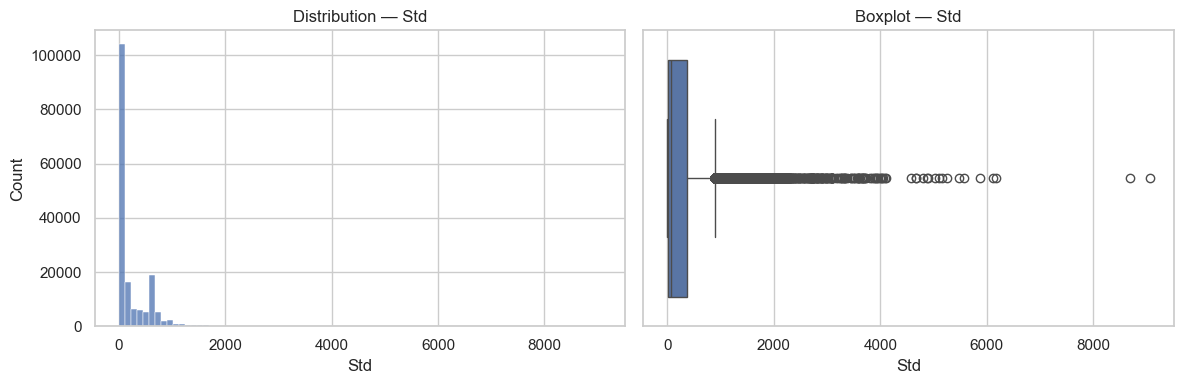

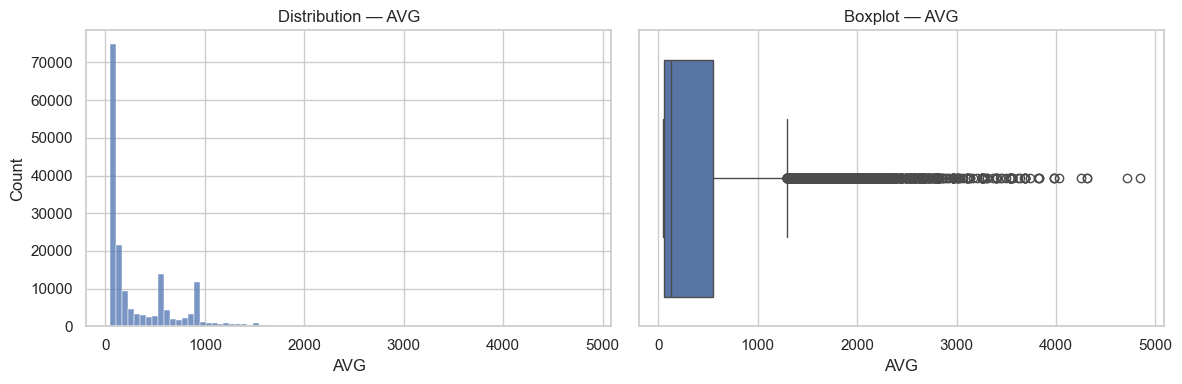

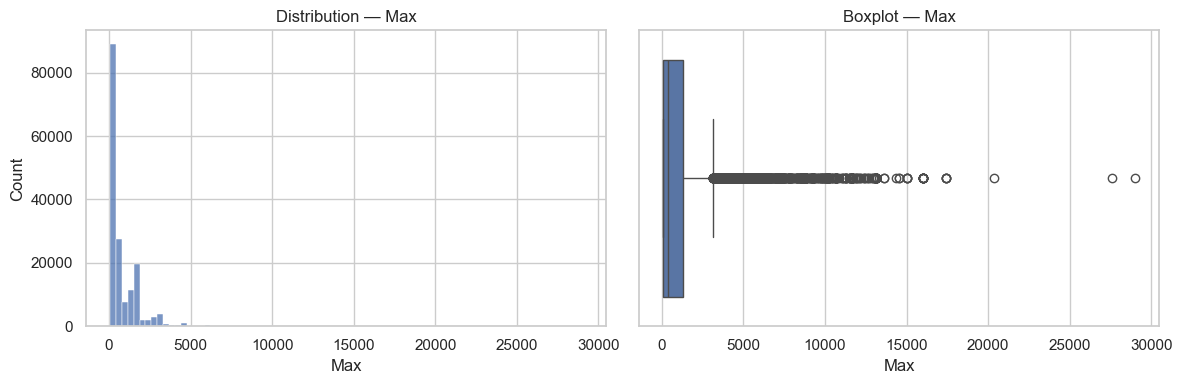

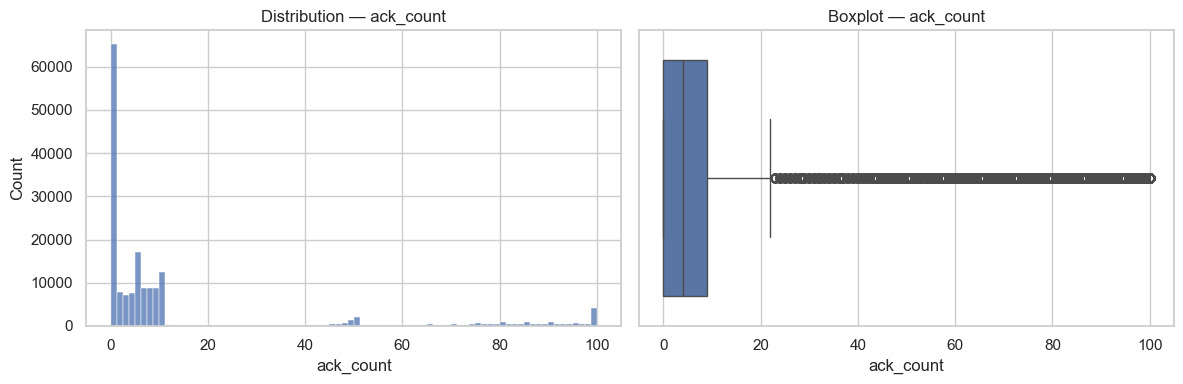

In [15]:

for col in plot_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(eda_df[col], bins=80, ax=axes[0], kde=False)
    axes[0].set_title(f"Distribution — {col}")
    sns.boxplot(x=eda_df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot — {col}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"dist_box_{col}.png", dpi=160, bbox_inches="tight")
    plt.show()


## 8. Correlation and redundancy

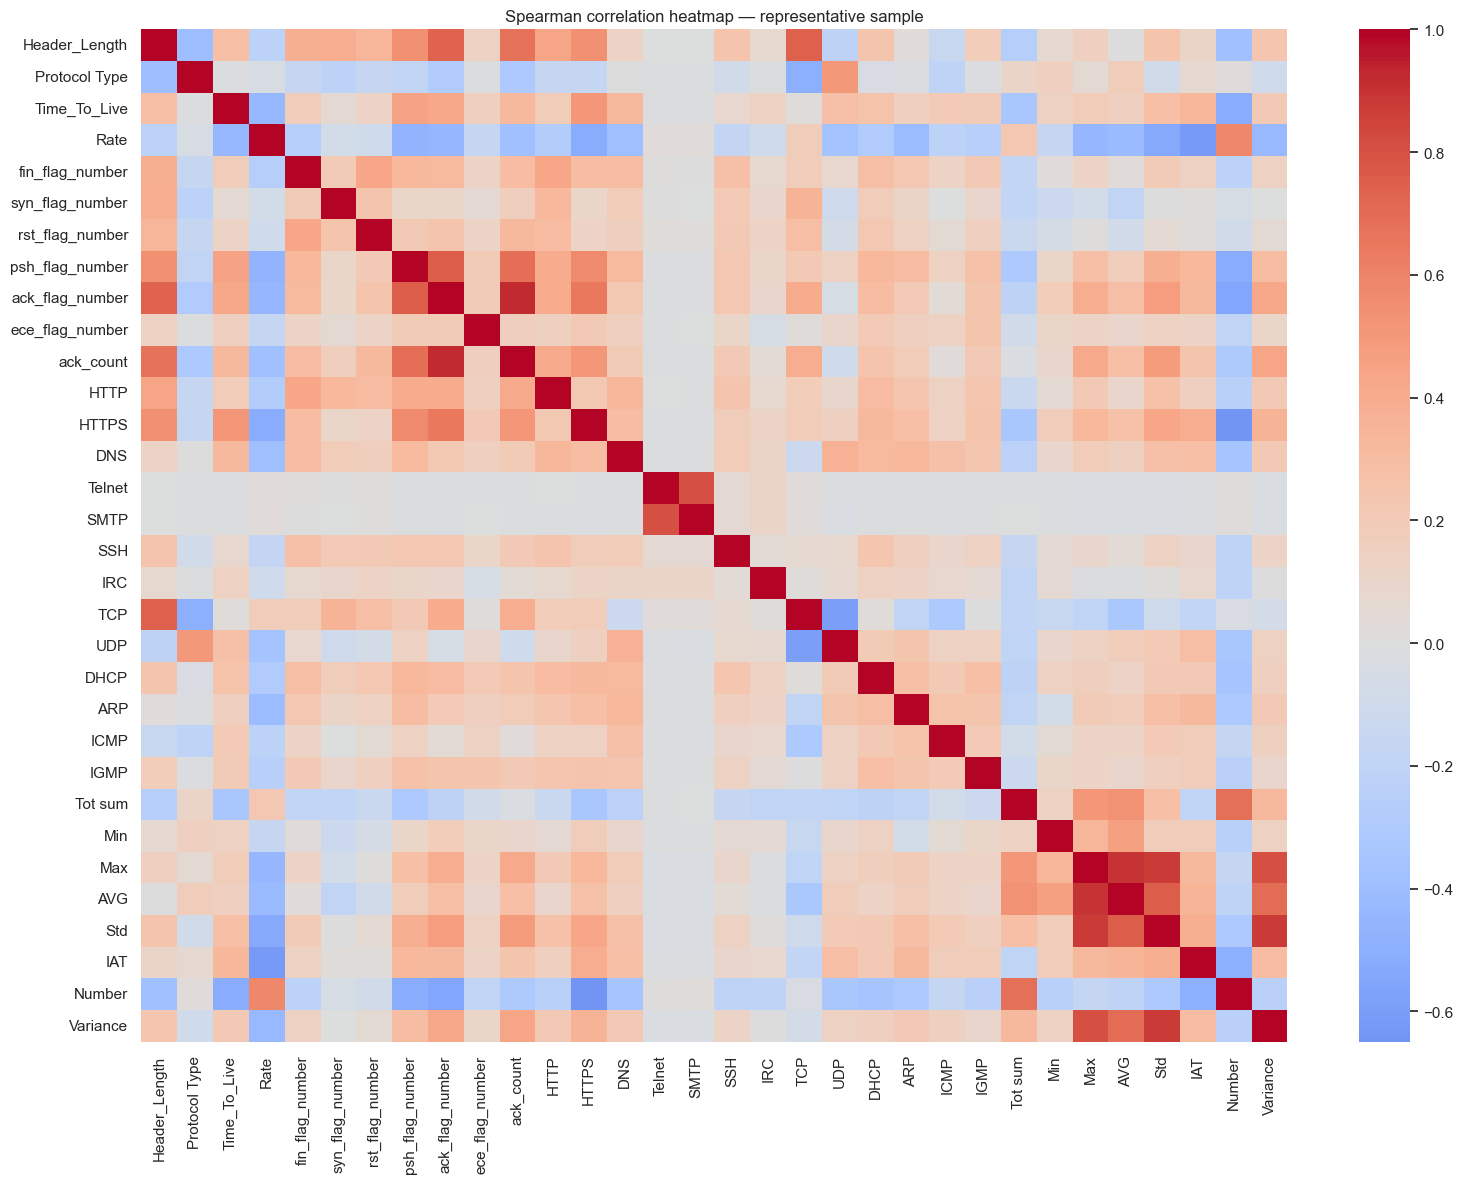

In [16]:

corr_sample = eda_df.sample(n=min(len(eda_df), CORR_ROWS), random_state=SEED)
corr_matrix = corr_sample[feature_cols].corr(method="spearman")

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Spearman correlation heatmap — representative sample")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap_eda.png", dpi=160, bbox_inches="tight")
plt.show()


In [17]:

high_corr_pairs_df = correlation_drop_candidates(corr_sample, feature_cols, threshold=HIGH_CORR_THRESHOLD)
high_corr_pairs_df.to_csv(REPORTS_DIR / "high_correlation_pairs_eda.csv", index=False)
high_corr_pairs_df.head(30)


,feature_a,feature_b,abs_spearman


## 9. Synthetic plausibility check — corrected version

In [18]:

plausibility_summary_df = None

if SYNTHETIC_ONLY_DATASET.exists() and BASE_BALANCED_DATASET.exists():
    base_full = read_csv_safely(BASE_BALANCED_DATASET)
    synth_full = read_csv_safely(SYNTHETIC_ONLY_DATASET)

    base_df = stratified_sample_per_class(base_full, LABEL_COL, n_per_class=3000, seed=SEED)
    synth_df = stratified_sample_per_class(synth_full, LABEL_COL, n_per_class=3000, seed=SEED)

    print("Base labels found :", sorted(base_df[LABEL_COL].unique()))
    print("Synth labels found:", sorted(synth_df[LABEL_COL].unique()))

    rows = []
    common_labels = sorted(set(base_df[LABEL_COL].unique()).intersection(set(synth_df[LABEL_COL].unique())))
    print("Common labels:", common_labels)

    for label in common_labels:
        real_part = base_df[base_df[LABEL_COL] == label]
        synth_part = synth_df[synth_df[LABEL_COL] == label]

        if len(real_part) == 0 or len(synth_part) == 0:
            continue

        for col in feature_cols:
            rows.append({
                "label": label,
                "feature": col,
                "real_mean": float(real_part[col].mean()),
                "synth_mean": float(synth_part[col].mean()),
                "abs_mean_diff": float(abs(real_part[col].mean() - synth_part[col].mean())),
                "real_std": float(real_part[col].std(ddof=0)),
                "synth_std": float(synth_part[col].std(ddof=0)),
            })

    if len(rows) > 0:
        plausibility_df = pd.DataFrame(rows)
        plausibility_df.to_csv(REPORTS_DIR / "synthetic_plausibility_report_stratified.csv", index=False)
        plausibility_summary_df = (
            plausibility_df.groupby("label")[["abs_mean_diff", "real_std", "synth_std"]]
            .mean()
            .reset_index()
            .sort_values("abs_mean_diff")
        )
        plausibility_summary_df.to_csv(REPORTS_DIR / "synthetic_plausibility_summary_stratified.csv", index=False)
    else:
        print("No common labels found between stratified samples.")
        plausibility_summary_df = pd.DataFrame(columns=["label", "abs_mean_diff", "real_std", "synth_std"])
else:
    plausibility_summary_df = pd.DataFrame(columns=["label", "abs_mean_diff", "real_std", "synth_std"])

plausibility_summary_df.head(20)


Base labels found : ['BACKDOOR_MALWARE', 'BENIGN', 'BROWSERHIJACKING', 'COMMANDINJECTION', 'DDOS-ACK_FRAGMENTATION', 'DDOS-HTTP_FLOOD', 'DDOS-ICMP_FLOOD', 'DDOS-ICMP_FRAGMENTATION', 'DDOS-PSHACK_FLOOD', 'DDOS-RSTFINFLOOD', 'DDOS-SLOWLORIS', 'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-SYN_FLOOD', 'DDOS-TCP_FLOOD', 'DDOS-UDP_FLOOD', 'DDOS-UDP_FRAGMENTATION', 'DICTIONARYBRUTEFORCE', 'DNS_SPOOFING', 'DOS-HTTP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-TCP_FLOOD', 'DOS-UDP_FLOOD', 'MIRAI-GREETH_FLOOD', 'MIRAI-GREIP_FLOOD', 'MIRAI-UDPPLAIN', 'MITM-ARPSPOOFING', 'RECON-HOSTDISCOVERY', 'RECON-OSSCAN', 'RECON-PINGSWEEP', 'RECON-PORTSCAN', 'SQLINJECTION', 'UPLOADING_ATTACK', 'VULNERABILITYSCAN', 'XSS']
Synth labels found: ['BACKDOOR_MALWARE', 'BROWSERHIJACKING', 'COMMANDINJECTION', 'DDOS-ACK_FRAGMENTATION', 'DDOS-HTTP_FLOOD', 'DDOS-SLOWLORIS', 'DDOS-UDP_FRAGMENTATION', 'DICTIONARYBRUTEFORCE', 'DNS_SPOOFING', 'DOS-HTTP_FLOOD', 'MITM-ARPSPOOFING', 'RECON-HOSTDISCOVERY', 'RECON-OSSCAN', 'RECON-PINGSWEEP', 'RECON-PORTSCAN'

,label,abs_mean_diff,real_std,synth_std
9,DOS-HTTP_FLOOD,35.018822,14914.087462,12056.562664
8,DNS_SPOOFING,63.081454,7830.443242,6271.002843
3,DDOS-ACK_FRAGMENTATION,98.903567,3916.703683,1230.581608
15,SQLINJECTION,170.500031,14932.714323,6792.352568
6,DDOS-UDP_FRAGMENTATION,187.164997,4162.704266,1003.342961
2,COMMANDINJECTION,257.533029,29863.372532,13955.266287
5,DDOS-SLOWLORIS,283.494797,21696.284479,15488.471835
13,RECON-PINGSWEEP,319.178721,25908.716936,16533.586936
4,DDOS-HTTP_FLOOD,337.763135,8014.125383,5436.185180
16,UPLOADING_ATTACK,346.190231,27477.593127,15017.414843


## 10. Split first, then clean train-only artifacts

In [19]:

full_df = full_input_df.copy()
model_df = full_df.copy()

train_df, test_df = train_test_split(
    model_df,
    test_size=TEST_RATIO,
    stratify=model_df[LABEL_COL],
    random_state=SEED,
)

if USE_VALIDATION:
    train_df, val_df = train_test_split(
        train_df,
        test_size=VAL_RATIO_FROM_TRAIN,
        stratify=train_df[LABEL_COL],
        random_state=SEED,
    )
else:
    val_df = None

print("Train shape before cleaning:", train_df.shape)
print("Val shape before cleaning  :", None if val_df is None else val_df.shape)
print("Test shape before cleaning :", test_df.shape)


Train shape before cleaning: (7140000, 34)
Val shape before cleaning  : (1020000, 34)
Test shape before cleaning : (2040000, 34)


## 11. Clean Inf / NaN and duplicates (train only)

In [20]:

def replace_inf_with_nan(df, cols):
    out = df.copy()
    out[cols] = out[cols].replace([np.inf, -np.inf], np.nan)
    return out

# Detect columns from train split
numeric_cols_train, feature_cols_train, object_cols_train = detect_feature_columns(train_df, LABEL_COL, LABEL_ID_COL_CANDIDATE)

train_df = replace_inf_with_nan(train_df, feature_cols_train)
test_df = replace_inf_with_nan(test_df, feature_cols_train)
if val_df is not None:
    val_df = replace_inf_with_nan(val_df, feature_cols_train)

train_dup_before = int(train_df.duplicated().sum())
if DROP_DUPLICATES_TRAIN_ONLY and train_dup_before > 0:
    train_df = train_df.drop_duplicates().reset_index(drop=True)

print("Train duplicates removed:", train_dup_before)
print("Train shape after train-only dedup:", train_df.shape)


Train duplicates removed: 0
Train shape after train-only dedup: (7140000, 34)


## 12. Feature selection decisions

In [21]:

# Audit based on TRAIN ONLY to avoid leakage
full_feature_quality_df = build_feature_quality_report(train_df, feature_cols_train)
full_feature_quality_df.to_csv(REPORTS_DIR / "feature_quality_report_train.csv", index=False)

constant_features_train = full_feature_quality_df.loc[full_feature_quality_df["is_constant"], "feature"].tolist()
near_constant_features_train = full_feature_quality_df.loc[full_feature_quality_df["is_near_constant"], "feature"].tolist()

features_to_drop = []
if REMOVE_CONSTANT_FEATURES:
    features_to_drop.extend(constant_features_train)
if REMOVE_NEAR_CONSTANT_FEATURES:
    features_to_drop.extend(near_constant_features_train)

features_to_drop = sorted(set(features_to_drop))
selected_feature_cols = [c for c in feature_cols_train if c not in features_to_drop]

print("Constant features (drop):", constant_features_train)
print("Near-constant features (review):", near_constant_features_train)
print("Final features dropped:", features_to_drop)
print("Selected feature count:", len(selected_feature_cols))


Constant features (drop): []
Near-constant features (review): ['Telnet', 'SMTP']
Final features dropped: []
Selected feature count: 32


In [22]:

if REMOVE_HIGH_CORR_FEATURES:
    corr_pairs_train = correlation_drop_candidates(
        train_df[selected_feature_cols].sample(min(len(train_df), 100_000), random_state=SEED),
        selected_feature_cols,
        threshold=HIGH_CORR_THRESHOLD,
    )
    corr_pairs_train.to_csv(REPORTS_DIR / "high_correlation_pairs_train.csv", index=False)
    to_drop_corr = set(corr_pairs_train["feature_b"].tolist())
    selected_feature_cols = [c for c in selected_feature_cols if c not in to_drop_corr]
    print("Dropped due to high correlation:", sorted(to_drop_corr))
    print("Selected feature count after corr filtering:", len(selected_feature_cols))


## 13. Imputation, optional log transform, scaling, label encoding, class weights

In [23]:

X_train = train_df[selected_feature_cols].copy()
y_train = train_df[LABEL_COL].copy()
X_test = test_df[selected_feature_cols].copy()
y_test = test_df[LABEL_COL].copy()
X_val = val_df[selected_feature_cols].copy() if val_df is not None else None
y_val = val_df[LABEL_COL].copy() if val_df is not None else None

imputer = SimpleImputer(strategy=MISSING_NUMERIC_STRATEGY)
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=selected_feature_cols, index=X_train.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=selected_feature_cols, index=X_test.index)
X_val_imp = pd.DataFrame(imputer.transform(X_val), columns=selected_feature_cols, index=X_val.index) if X_val is not None else None

log1p_applied_features = []
if APPLY_LOG1P_TO_HEAVY_SKEW:
    X_train_imp, X_val_imp, X_test_imp, log1p_applied_features = optional_log1p_transform(
        X_train_imp, X_val_imp, X_test_imp, selected_feature_cols, skew_threshold=SKEW_THRESHOLD_FOR_LOG1P
    )

scaler = fit_scaler(SCALER_NAME)
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=selected_feature_cols, index=X_train_imp.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=selected_feature_cols, index=X_test_imp.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val_imp), columns=selected_feature_cols, index=X_val_imp.index) if X_val_imp is not None else None

if CAST_FLOAT32:
    X_train_scaled = X_train_scaled.astype(np.float32)
    X_test_scaled = X_test_scaled.astype(np.float32)
    if X_val_scaled is not None:
        X_val_scaled = X_val_scaled.astype(np.float32)

label_encoder = LabelEncoder()
y_train_enc = pd.Series(label_encoder.fit_transform(y_train), index=y_train.index, name="label_id")
y_test_enc = pd.Series(label_encoder.transform(y_test), index=y_test.index, name="label_id")
y_val_enc = pd.Series(label_encoder.transform(y_val), index=y_val.index, name="label_id") if y_val is not None else None

classes = label_encoder.classes_
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights_df = pd.DataFrame({"label": classes, "class_weight": class_weights})
class_weights_df["label_id"] = range(len(class_weights_df))

print("Selected feature count:", len(selected_feature_cols))
print("Number of classes:", len(classes))
class_weights_df.head()


Selected feature count: 32
Number of classes: 34


,label,class_weight,label_id
0,BACKDOOR_MALWARE,1.0,0
1,BENIGN,1.0,1
2,BROWSERHIJACKING,1.0,2
3,COMMANDINJECTION,1.0,3
4,DDOS-ACK_FRAGMENTATION,1.0,4


## 14. Final export tables and arrays

In [24]:

train_ready = pd.concat([X_train_scaled.reset_index(drop=True), y_train.reset_index(drop=True), y_train_enc.reset_index(drop=True)], axis=1)
test_ready = pd.concat([X_test_scaled.reset_index(drop=True), y_test.reset_index(drop=True), y_test_enc.reset_index(drop=True)], axis=1)
val_ready = pd.concat([X_val_scaled.reset_index(drop=True), y_val.reset_index(drop=True), y_val_enc.reset_index(drop=True)], axis=1) if X_val_scaled is not None else None

if EXPORT_CSV:
    train_ready.to_csv(EXPORTS_DIR / "train_ready.csv", index=False)
    test_ready.to_csv(EXPORTS_DIR / "test_ready.csv", index=False)
    if val_ready is not None:
        val_ready.to_csv(EXPORTS_DIR / "val_ready.csv", index=False)

if EXPORT_PARQUET:
    train_ready.to_parquet(EXPORTS_DIR / "train_ready.parquet", index=False)
    test_ready.to_parquet(EXPORTS_DIR / "test_ready.parquet", index=False)
    if val_ready is not None:
        val_ready.to_parquet(EXPORTS_DIR / "val_ready.parquet", index=False)

if EXPORT_NPZ:
    np.savez_compressed(EXPORTS_DIR / "train_ready_arrays.npz", X=X_train_scaled.values, y=y_train_enc.values)
    np.savez_compressed(EXPORTS_DIR / "test_ready_arrays.npz", X=X_test_scaled.values, y=y_test_enc.values)
    if val_ready is not None:
        np.savez_compressed(EXPORTS_DIR / "val_ready_arrays.npz", X=X_val_scaled.values, y=y_val_enc.values)

with open(ARTIFACTS_DIR / "imputer.pkl", "wb") as f:
    pickle.dump(imputer, f)
with open(ARTIFACTS_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open(ARTIFACTS_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
with open(ARTIFACTS_DIR / "class_weights_34.pkl", "wb") as f:
    pickle.dump(class_weights_df, f)

pd.DataFrame({"feature": selected_feature_cols, "order": range(len(selected_feature_cols))}).to_csv(ARTIFACTS_DIR / "selected_features.csv", index=False)
pd.DataFrame({"label": label_encoder.classes_, "label_id": range(len(label_encoder.classes_))}).to_csv(ARTIFACTS_DIR / "label_mapping.csv", index=False)
class_weights_df.to_csv(ARTIFACTS_DIR / "class_weights_34.csv", index=False)

print("Exports saved to  :", EXPORTS_DIR)
print("Artifacts saved to:", ARTIFACTS_DIR)


Exports saved to  : E:\dataset\processed_merged_full\minority_balancing_v3\post_balancing_preprocessing_professional_v2\exports
Artifacts saved to: E:\dataset\processed_merged_full\minority_balancing_v3\post_balancing_preprocessing_professional_v2\artifacts


## 15. Before / after preprocessing comparison and retention ratios

In [25]:

# Before/after class distribution
class_before = full_input_df[LABEL_COL].value_counts().sort_index()
class_after = pd.concat([train_ready[[LABEL_COL]], test_ready[[LABEL_COL]], val_ready[[LABEL_COL]] if val_ready is not None else pd.DataFrame(columns=[LABEL_COL])])[LABEL_COL].value_counts().sort_index()

compare_dist_df = pd.DataFrame({
    "count_before": class_before,
    "count_after": class_after,
})
compare_dist_df["retention_ratio"] = compare_dist_df["count_after"] / compare_dist_df["count_before"]
compare_dist_df = compare_dist_df.reset_index().rename(columns={"index": "label"})
compare_dist_df.to_csv(REPORTS_DIR / "class_distribution_before_after_preprocessing.csv", index=False)
compare_dist_df.head(20)


,label,count_before,count_after,retention_ratio
0,BACKDOOR_MALWARE,300000,300000,1.0
1,BENIGN,300000,300000,1.0
2,BROWSERHIJACKING,300000,300000,1.0
3,COMMANDINJECTION,300000,300000,1.0
4,DDOS-ACK_FRAGMENTATION,300000,300000,1.0
5,DDOS-HTTP_FLOOD,300000,300000,1.0
6,DDOS-ICMP_FLOOD,300000,300000,1.0
7,DDOS-ICMP_FRAGMENTATION,300000,300000,1.0
8,DDOS-PSHACK_FLOOD,300000,300000,1.0
9,DDOS-RSTFINFLOOD,300000,300000,1.0


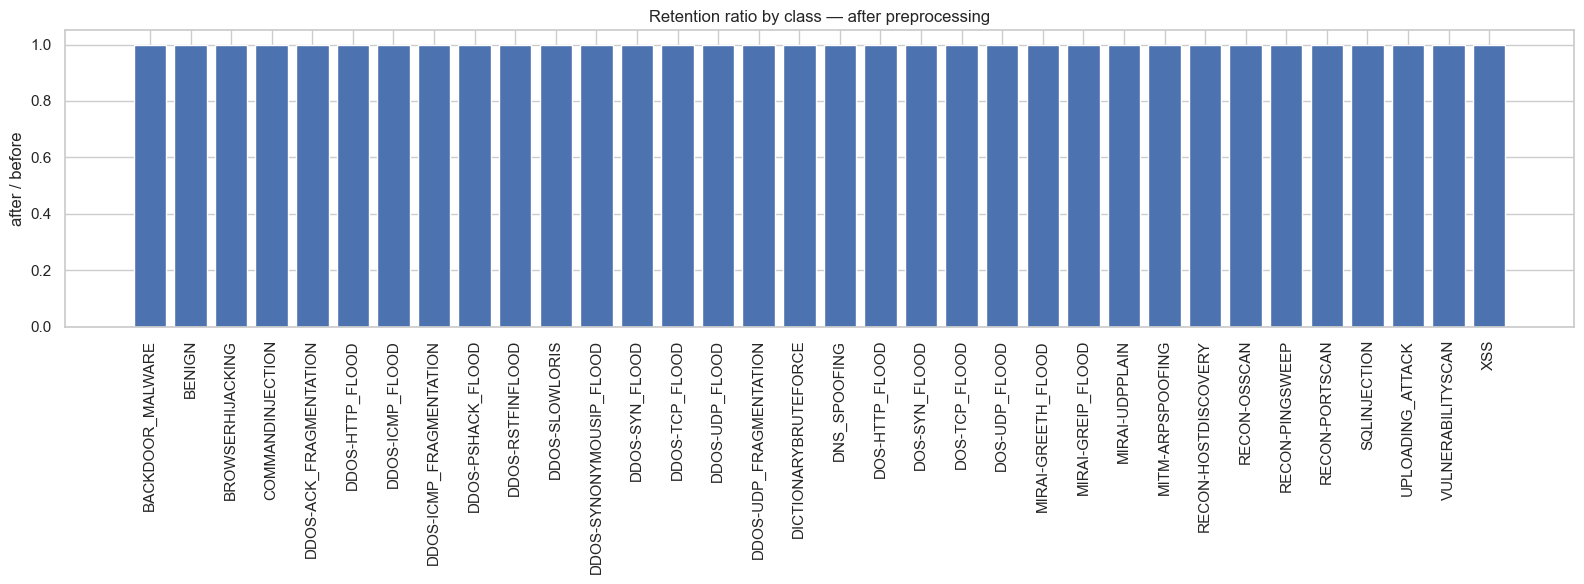

In [26]:

plt.figure(figsize=(16, 6))
plt.bar(compare_dist_df["label"], compare_dist_df["retention_ratio"])
plt.title("Retention ratio by class — after preprocessing")
plt.ylabel("after / before")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_retention_ratio_after_preprocessing.png", dpi=160, bbox_inches="tight")
plt.show()


In [27]:

# Rows and features comparison figure
comparison_metrics = pd.DataFrame([
    {"stage": "balanced_input", "rows": len(full_input_df), "features": len(feature_cols_train)},
    {"stage": "train_ready", "rows": len(train_ready), "features": len(selected_feature_cols)},
    {"stage": "val_ready", "rows": 0 if val_ready is None else len(val_ready), "features": len(selected_feature_cols)},
    {"stage": "test_ready", "rows": len(test_ready), "features": len(selected_feature_cols)},
])
comparison_metrics.to_csv(REPORTS_DIR / "dataset_size_before_after_preprocessing.csv", index=False)
comparison_metrics


,stage,rows,features
0,balanced_input,10200000,32
1,train_ready,7140000,32
2,val_ready,1020000,32
3,test_ready,2040000,32


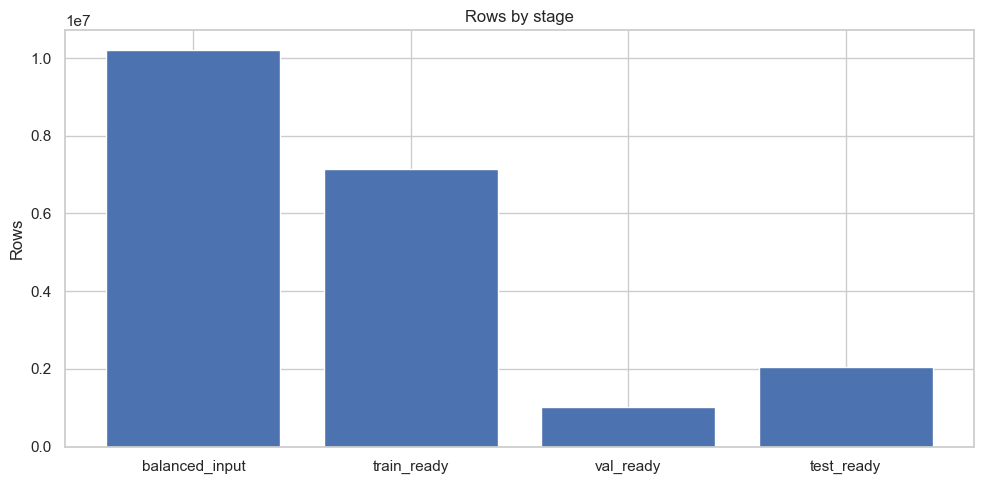

In [28]:

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(comparison_metrics["stage"], comparison_metrics["rows"])
ax.set_title("Rows by stage")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rows_by_stage.png", dpi=160, bbox_inches="tight")
plt.show()


## 16. Sanity checks

In [29]:

sanity = {
    "train_has_nan": bool(np.isnan(X_train_scaled.values).any()),
    "test_has_nan": bool(np.isnan(X_test_scaled.values).any()),
    "val_has_nan": bool(np.isnan(X_val_scaled.values).any()) if X_val_scaled is not None else False,
    "train_has_inf": bool(np.isinf(X_train_scaled.values).any()),
    "test_has_inf": bool(np.isinf(X_test_scaled.values).any()),
    "val_has_inf": bool(np.isinf(X_val_scaled.values).any()) if X_val_scaled is not None else False,
    "n_selected_features": int(len(selected_feature_cols)),
    "n_classes": int(len(label_encoder.classes_)),
    "train_rows": int(len(train_ready)),
    "val_rows": int(0 if val_ready is None else len(val_ready)),
    "test_rows": int(len(test_ready)),
}

save_json(sanity, REPORTS_DIR / "sanity_checks.json")
sanity


{'train_has_nan': False,
 'test_has_nan': False,
 'val_has_nan': False,
 'train_has_inf': False,
 'test_has_inf': False,
 'val_has_inf': False,
 'n_selected_features': 32,
 'n_classes': 34,
 'train_rows': 7140000,
 'val_rows': 1020000,
 'test_rows': 2040000}

## 17. Compact preprocessing report

In [31]:

report_lines = []
report_lines.append("# Post-Balancing Preprocessing Report — v2")
report_lines.append("")
report_lines.append(f"- Input dataset: `{INPUT_DATASET}`")
report_lines.append(f"- Full balanced rows: `{len(full_input_df):,}`")
report_lines.append(f"- Selected features: `{len(selected_feature_cols)}`")
report_lines.append(f"- Constant features dropped: `{constant_features_train}`")
report_lines.append(f"- Near-constant features under review: `{near_constant_features_train}`")
report_lines.append(f"- Final dropped features: `{features_to_drop}`")
report_lines.append(f"- Scaler: `{SCALER_NAME}`")
report_lines.append(f"- Missing strategy: `{MISSING_NUMERIC_STRATEGY}`")
report_lines.append(f"- Log1p applied: `{APPLY_LOG1P_TO_HEAVY_SKEW}`")
report_lines.append(f"- Train shape: `{train_ready.shape}`")
report_lines.append(f"- Val shape: `{None if val_ready is None else val_ready.shape}`")
report_lines.append(f"- Test shape: `{test_ready.shape}`")
report_lines.append("")
report_lines.append("## Main findings")
report_lines.append("")
report_lines.append("- The dataset is already mostly numeric except for the class label.")
report_lines.append("- Representative EDA must be stratified by class, not based on the top rows of the CSV.")
report_lines.append("- Constant features are removed automatically; near-constant features are reviewed before deletion.")
report_lines.append("- Scaling, label encoding, and class-weight computation are all fit on train only.")
report_lines.append("- The final artifacts are ready for centralized, hierarchical, and federated pipelines.")

report_path = "PREPROCESSING_REPORT_v2.md"
report_path.write_text("
".join(report_lines), encoding="utf-8")
print("Saved report:", report_path)


SyntaxError: unterminated string literal (detected at line 26) (444356380.py, line 26)


## 18. Recommended next steps

1. Review `feature_quality_report_train.csv` and confirm whether to manually drop some near-constant features.
2. Review `high_correlation_pairs_eda.csv` and decide whether to activate correlated-feature removal.
3. Re-train the flat baseline and hierarchical pipeline on the new `train_ready / val_ready / test_ready` exports.
4. Reuse `selected_features.csv`, `scaler.pkl`, `label_encoder.pkl`, and `class_weights_34.pkl` in your FL experiments.
5. If needed, create a second version with controlled correlation pruning and compare macro-F1, benign recall, and balanced accuracy.
